In [1]:
!pip install pandas openpyxl matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
file_path = 'Superstore.xlsx'  # Update this path to your actual file location
df = pd.read_excel(file_path)

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [5]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [6]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
print(df.shape)

(9994, 13)


In [13]:
print(df.columns.tolist())

['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


In [14]:
print(df['Region'].value_counts())
print(df['Category'].value_counts())
print(df['Segment'].value_counts())
print(df['Ship Mode'].value_counts())
print(df['Sub-Category'].value_counts())
print(df['State'].value_counts().head(10))
print(df['State'].value_counts().tail(10))

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64
Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64
State
California        2001
New York          1128
Texas              985
Pennsylvania       587
Washington         506
Illinois           492
Ohio               469
Florida            383
Michi

In [15]:
print(df['State'].value_counts().head(10))
print(df['State'].value_counts().tail(10))

State
California        2001
New York          1128
Texas              985
Pennsylvania       587
Washington         506
Illinois           492
Ohio               469
Florida            383
Michigan           255
North Carolina     249
Name: count, dtype: int64
State
Kansas                  24
Idaho                   21
Montana                 15
South Dakota            12
Vermont                 11
District of Columbia    10
Maine                    8
North Dakota             7
West Virginia            4
Wyoming                  1
Name: count, dtype: int64


In [16]:
#Region-profit analysis
print(df.groupby('Region')['Profit'].sum().sort_values(ascending=False))

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [19]:
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False))

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [20]:
region_summary = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
print(region_summary)

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303


Text(0, 0.5, 'Total Profit')

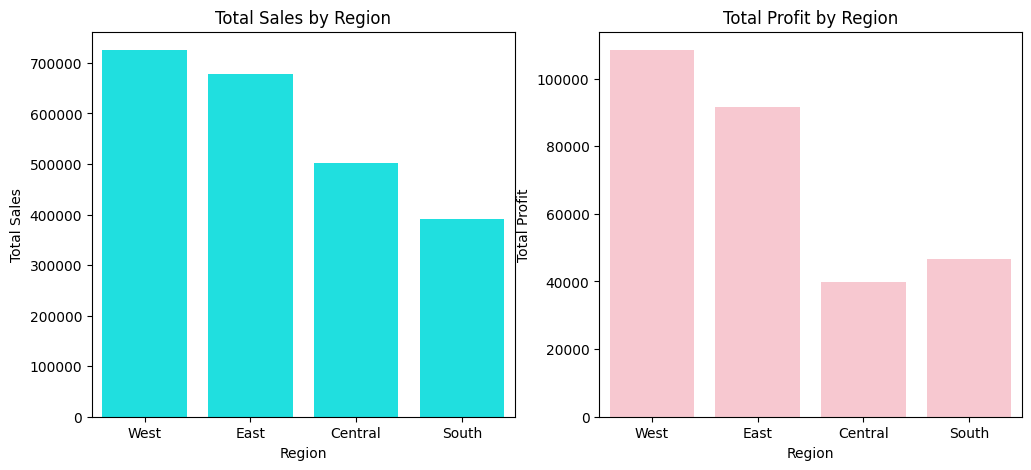

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

#sales by region
sns.barplot(x=region_summary.index, y=region_summary['Sales'], ax=axes[0], color='cyan')
axes[0].set_title('Total Sales by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales')

#profit by region
sns.barplot(x=region_summary.index, y=region_summary['Profit'], ax=axes[1], color='pink')
axes[1].set_title('Total Profit by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Profit')

In [26]:
#state-wise sales and profit
state_summary = df.groupby('State').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
print(state_summary.head(10))
print(state_summary.tail(10))

                    Sales      Profit
State                                
California    457687.6315  76381.3871
New York      310876.2710  74038.5486
Texas         170188.0458 -25729.3563
Washington    138641.2700  33402.6517
Pennsylvania  116511.9140 -15559.9603
Florida        89473.7080  -3399.3017
Illinois       80166.1010 -12607.8870
Ohio           78258.1360 -16971.3766
Michigan       76269.6140  24463.1876
Virginia       70636.7200  18597.9504
                         Sales     Profit
State                                    
New Mexico            4783.522  1157.1161
Iowa                  4579.760  1183.8119
Idaho                 4382.486   826.7231
Kansas                2914.310   836.4435
District of Columbia  2865.020  1059.5893
Wyoming               1603.136   100.1960
South Dakota          1315.560   394.8283
Maine                 1270.530   454.4862
West Virginia         1209.824   185.9216
North Dakota           919.910   230.1497


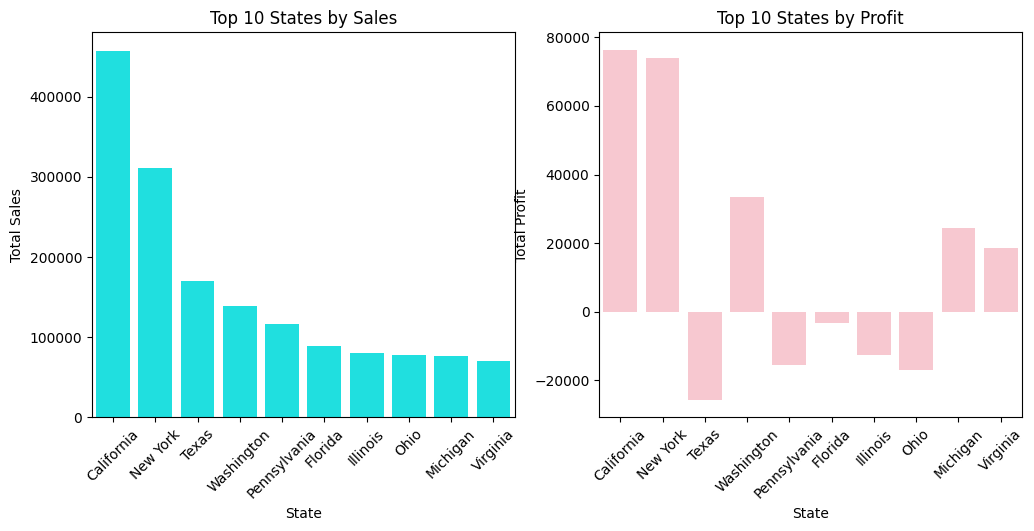

In [30]:
#top 10 states by sales and profit
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.barplot(x=state_summary.head(10).index, y=state_summary.head(10)['Sales'], ax=axes[0], color='cyan')
axes[0].set_title('Top 10 States by Sales')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x=state_summary.head(10).index, y=state_summary.head(10)['Profit'], ax=axes[1], color='pink')
axes[1].set_title('Top 10 States by Profit')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Total Profit')
axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)

In [31]:
# sales and profit by category
category_summary = df.groupby('Category').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
print(category_summary)

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


In [ ]:
# drill down to sub-category level
subcategory_summary = df.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
print(subcategory_summary)

                    Sales      Profit
Sub-Category                         
Phones        330007.0540  44515.7306
Chairs        328449.1030  26590.1663
Storage       223843.6080  21278.8264
Tables        206965.5320 -17725.4811
Binders       203412.7330  30221.7633
Machines      189238.6310   3384.7569
Accessories   167380.3180  41936.6357
Copiers       149528.0300  55617.8249
Bookcases     114879.9963  -3472.5560
Appliances    107532.1610  18138.0054
Furnishings    91705.1640  13059.1436
Paper          78479.2060  34053.5693
Supplies       46673.5380  -1189.0995
Art            27118.7920   6527.7870
Envelopes      16476.4020   6964.1767
Labels         12486.3120   5546.2540
Fasteners       3024.2800    949.5182


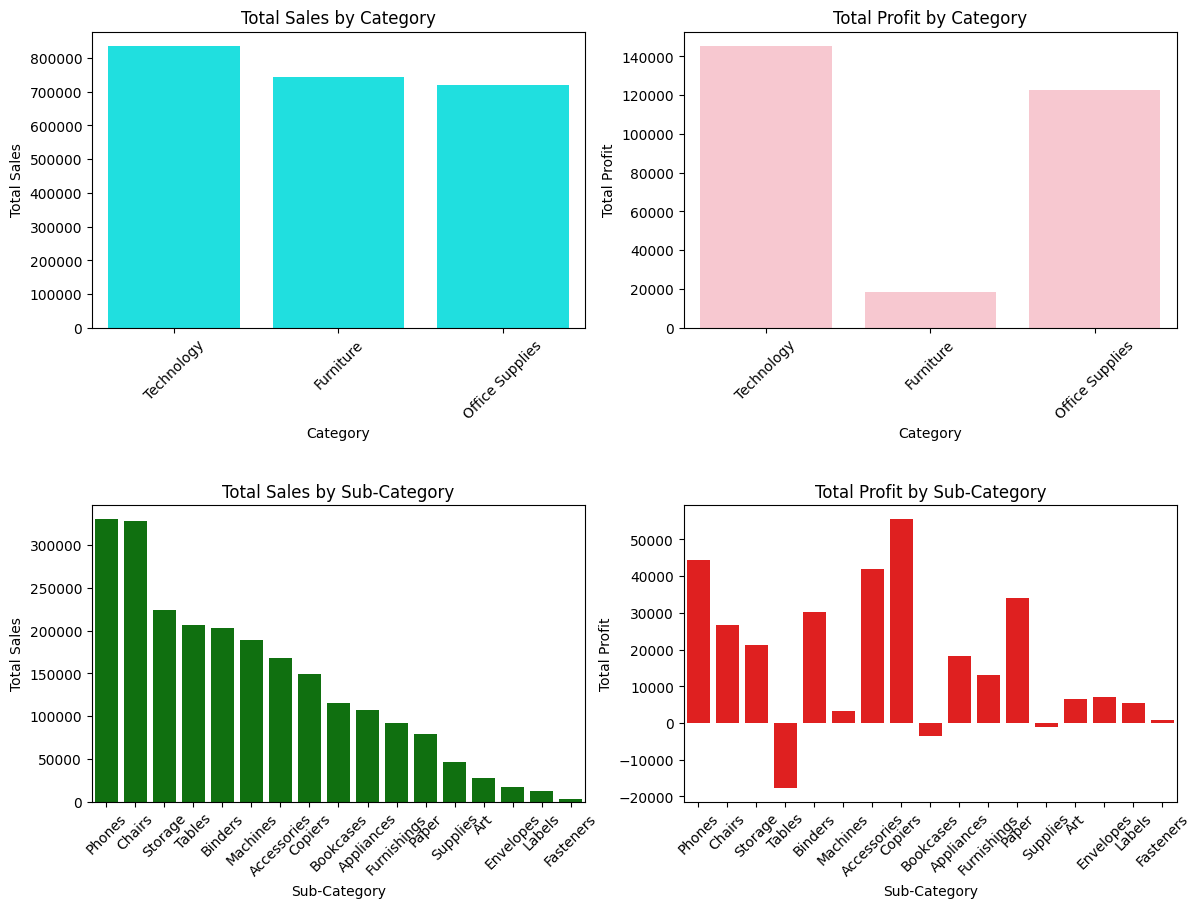

In [37]:
# charts for category and sub-category
fig, axes = plt.subplots(2, 2, figsize=(14,10))
sns.barplot(x=category_summary.index, y=category_summary['Sales'], ax=axes[0,0], color='cyan')
axes[0,0].set_title('Total Sales by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Total Sales')
axes[0,0].tick_params(axis='x', rotation=45)
sns.barplot(x=category_summary.index, y=category_summary['Profit'], ax=axes[0,1], color='pink')
axes[0,1].set_title('Total Profit by Category')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Total Profit')
axes[0,1].tick_params(axis='x', rotation=45)
sns.barplot(x=subcategory_summary.index, y=subcategory_summary['Sales'], ax=axes[1,0], color='green')
axes[1,0].set_title('Total Sales by Sub-Category')
axes[1,0].set_xlabel('Sub-Category')
axes[1,0].set_ylabel('Total Sales')
axes[1,0].tick_params(axis='x', rotation=45)
sns.barplot(x=subcategory_summary.index, y=subcategory_summary['Profit'], ax=axes[1,1], color='red')
axes[1,1].set_title('Total Profit by Sub-Category')
axes[1,1].set_xlabel('Sub-Category')
axes[1,1].set_ylabel('Total Profit')
axes[1,1].tick_params(axis='x', rotation=45)
plt.subplots_adjust(hspace=0.6)

In [38]:
#discount analysis
discount_summary = df.groupby('Discount').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
print(discount_summary)

                 Sales       Profit
Discount                           
0.00      1.087908e+06  320987.6032
0.20      7.645944e+05   90337.3060
0.40      1.164178e+05  -23057.0504
0.30      1.032267e+05  -10369.2774
0.50      5.891854e+04  -20506.4281
0.10      5.436935e+04    9029.1770
0.70      4.062028e+04  -40075.3569
0.15      2.755852e+04    1418.9915
0.80      1.696376e+04  -30539.0392
0.32      1.449346e+04   -2391.1377
0.60      6.644700e+03   -5944.6552
0.45      5.484974e+03   -2493.1111


Text(0, 0.5, 'Total Profit')

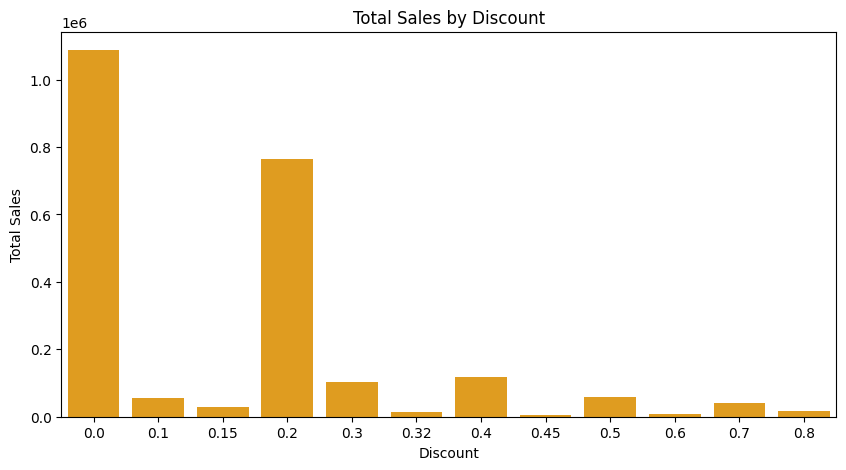

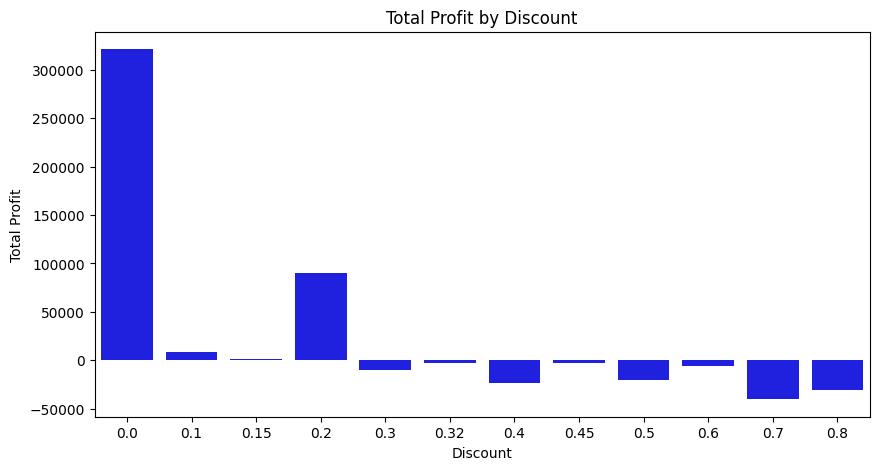

In [40]:
plt.figure(figsize=(10,5))
sns.barplot(x=discount_summary.index, y=discount_summary['Sales'], color='orange')
plt.title('Total Sales by Discount')
plt.xlabel('Discount')
plt.ylabel('Total Sales')


plt.figure(figsize=(10,5))
sns.barplot(x=discount_summary.index, y=discount_summary['Profit'], color='blue')
plt.title('Total Profit by Discount')
plt.xlabel('Discount')
plt.ylabel('Total Profit')

In [43]:
segment_summary = df.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
print(segment_summary)

                    Sales       Profit
Segment                               
Consumer     1.161401e+06  134119.2092
Corporate    7.061464e+05   91979.1340
Home Office  4.296531e+05   60298.6785


In [44]:
segment_summary['Profit_Margin'] = (segment_summary['Profit'] / segment_summary['Sales'] * 100).round(2)
print(segment_summary)

                    Sales       Profit  Profit_Margin
Segment                                              
Consumer     1.161401e+06  134119.2092          11.55
Corporate    7.061464e+05   91979.1340          13.03
Home Office  4.296531e+05   60298.6785          14.03


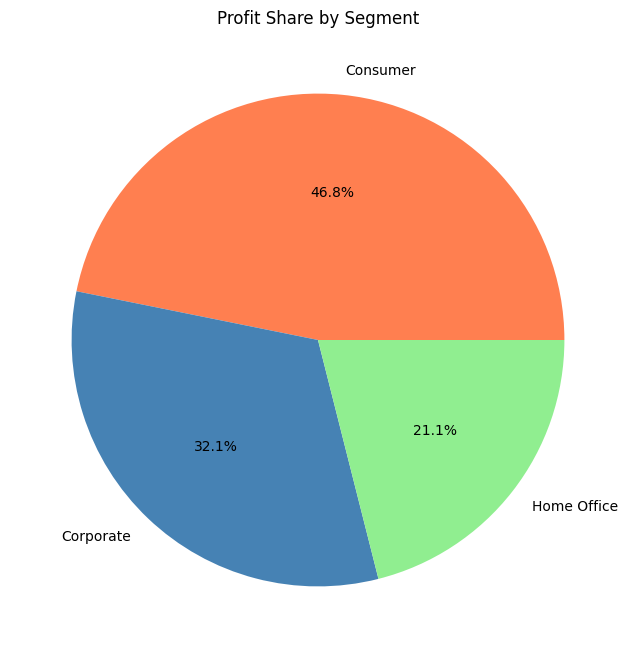

In [45]:
plt.figure(figsize=(8, 8))
plt.pie(segment_summary['Profit'], 
        labels=segment_summary.index, 
        autopct='%1.1f%%',
        colors=['coral', 'steelblue', 'lightgreen'])
plt.title('Profit Share by Segment')
plt.show()

In [49]:
# ship mode analysis
ship_mode_summary = df.groupby('Ship Mode').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False)
pd.options.display.float_format = '{:.2f}'.format
print(ship_mode_summary)

                    Sales    Profit
Ship Mode                          
Standard Class 1358215.74 164088.79
Second Class    459193.57  57446.64
First Class     351428.42  48969.84
Same Day        128363.12  15891.76


In [50]:
ship_mode_summary['Profit_Margin'] = (ship_mode_summary['Profit'] / ship_mode_summary['Sales'] * 100).round(2)
print(ship_mode_summary)

                    Sales    Profit  Profit_Margin
Ship Mode                                         
Standard Class 1358215.74 164088.79          12.08
Second Class    459193.57  57446.64          12.51
First Class     351428.42  48969.84          13.93
Same Day        128363.12  15891.76          12.38


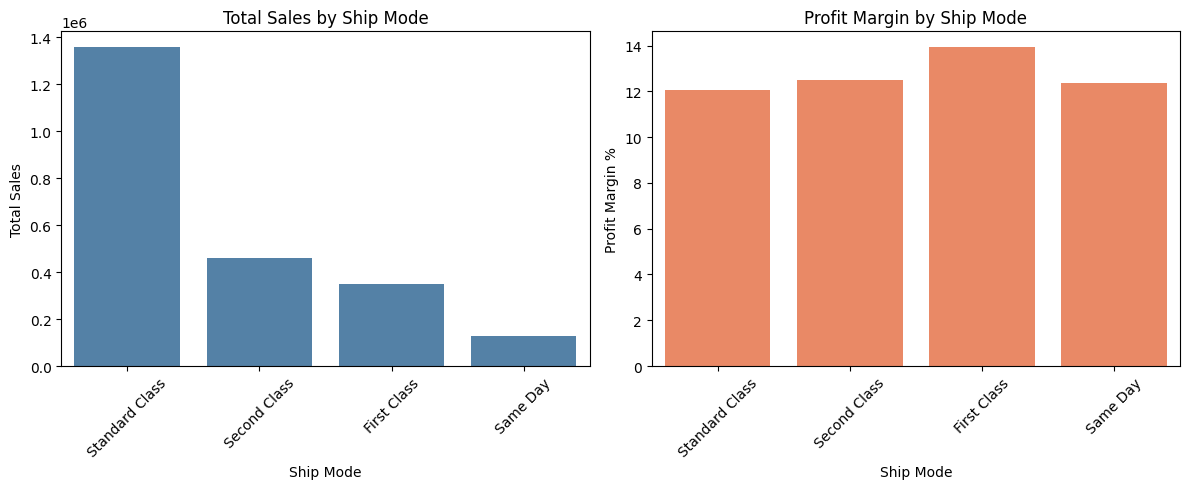

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=ship_mode_summary.index, y=ship_mode_summary['Sales'], ax=axes[0], color='steelblue')
axes[0].set_title('Total Sales by Ship Mode')
axes[0].set_xlabel('Ship Mode')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=ship_mode_summary.index, y=ship_mode_summary['Profit_Margin'], ax=axes[1], color='coral')
axes[1].set_title('Profit Margin by Ship Mode')
axes[1].set_xlabel('Ship Mode')
axes[1].set_ylabel('Profit Margin %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [52]:
df.to_csv('superstore_cleaned.csv', index=False)